In [2]:
import pandas as pd
DATA_PATH = "D:\\DS Assignment\\blogs.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())


Shape: (2000, 2)
Columns: ['Data', 'Labels']


,Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism


In [ ]:
print("Missing values per column:\n", df.isnull().sum())

if 'Labels' not in df.columns and 'Category' in df.columns:
    df.rename(columns={'Category':'Labels'}, inplace=True)
if 'Data' not in df.columns and 'Text' in df.columns:
    df.rename(columns={'Text':'Data'}, inplace=True)

print("Using columns: Data (text) and Labels (target).")
print("Unique labels:", df['Labels'].nunique())
print("Label distribution:\n", df['Labels'].value_counts())


Missing values per column:
 Data      0
Labels    0
dtype: int64
Using columns: Data (text) and Labels (target).
Unique labels: 20
Label distribution:
 Labels
alt.atheism                 100
comp.graphics               100
talk.politics.misc          100
talk.politics.mideast       100
talk.politics.guns          100
soc.religion.christian      100
sci.space                   100
sci.med                     100
sci.electronics             100
sci.crypt                   100
rec.sport.hockey            100
rec.sport.baseball          100
rec.motorcycles             100
rec.autos                   100
misc.forsale                100
comp.windows.x              100
comp.sys.mac.hardware       100
comp.sys.ibm.pc.hardware    100
comp.os.ms-windows.misc     100
talk.religion.misc          100
Name: count, dtype: int64


In [ ]:
import re
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+',' ', text)      
    text = re.sub(r'\S+@\S+',' ', text)               
    text = re.sub(r'[^a-z0-9\s]', ' ', text)         
    text = re.sub(r'\s+', ' ', text).strip()          
    return text

df['cleaned'] = df['Data'].apply(clean_text)

for i in range(3):
    print("ORIG:", df['Data'].iloc[i][:200])
    print("CLEAN:", df['cleaned'].iloc[i][:200])
    print("---")


ORIG: Path: cantaloupe.srv.cs.cmu.edu!magnesium.club.cc.cmu.edu!news.sei.cmu.edu!cis.ohio-state.edu!zaphod.mps.ohio-state.edu!howland.reston.ans.net!agate!doc.ic.ac.uk!uknet!mcsun!Germany.EU.net!thoth.mchp.
CLEAN: path cantaloupe srv cs cmu edu magnesium club cc cmu edu news sei cmu edu cis ohio state edu zaphod mps ohio state edu howland reston ans net agate doc ic ac uk uknet mcsun germany eu net thoth mchp s
---
ORIG: Newsgroups: alt.atheism
Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv.cs.cmu.edu!bb3.andrew.cmu.edu!news.sei.cmu.edu!cis.ohio-state.edu!zaphod.mps.ohio-state.edu!moe.ksu.ksu.edu!osuunx.ucc.okstate.edu
CLEAN: newsgroups alt atheism path cantaloupe srv cs cmu edu crabapple srv cs cmu edu bb3 andrew cmu edu news sei cmu edu cis ohio state edu zaphod mps ohio state edu moe ksu ksu edu osuunx ucc okstate edu c
---
ORIG: Path: cantaloupe.srv.cs.cmu.edu!das-news.harvard.edu!noc.near.net!uunet!olivea!hal.com!decwrl!usenet.coe.montana.edu!news.u.washington.edu!carson.u.washingt

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df['cleaned'])
y = df['Labels'].astype(str)
print("TF-IDF shape:", X.shape)
print("Sample features:", tfidf.get_feature_names_out()[:30])


TF-IDF shape: (2000, 5000)
Sample features: ['00' '00 gmt' '000' '01' '01 gmt' '02' '02 gmt' '03' '03 gmt' '04'
 '04 gmt' '0400' '0400 organization' '05' '05 gmt' '0500'
 '0500 organization' '06' '06 gmt' '07' '07 gmt' '0700' '08' '08 gmt' '09'
 '09 gmt' '0x60' '10' '10 00' '10 gmt']


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

clf = MultinomialNB()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Sample predictions:", y_pred[:10])


Train shape: (1600, 5000) Test shape: (400, 5000)
Sample predictions: ['sci.crypt' 'sci.med' 'talk.politics.mideast' 'soc.religion.christian'
 'talk.politics.guns' 'sci.med' 'comp.windows.x' 'rec.motorcycles'
 'talk.politics.mideast' 'comp.graphics']


Accuracy: 0.92
Classification report:
                           precision    recall  f1-score   support

             alt.atheism       1.00      0.65      0.79        20
           comp.graphics       0.90      0.90      0.90        20
 comp.os.ms-windows.misc       0.95      1.00      0.98        20
comp.sys.ibm.pc.hardware       0.83      1.00      0.91        20
   comp.sys.mac.hardware       1.00      0.95      0.97        20
          comp.windows.x       0.94      0.85      0.89        20
            misc.forsale       0.91      1.00      0.95        20
               rec.autos       0.91      1.00      0.95        20
         rec.motorcycles       1.00      0.95      0.97        20
      rec.sport.baseball       1.00      1.00      1.00        20
        rec.sport.hockey       1.00      1.00      1.00        20
               sci.crypt       0.95      1.00      0.98        20
         sci.electronics       1.00      0.85      0.92        20
                 sci.med       1.00 

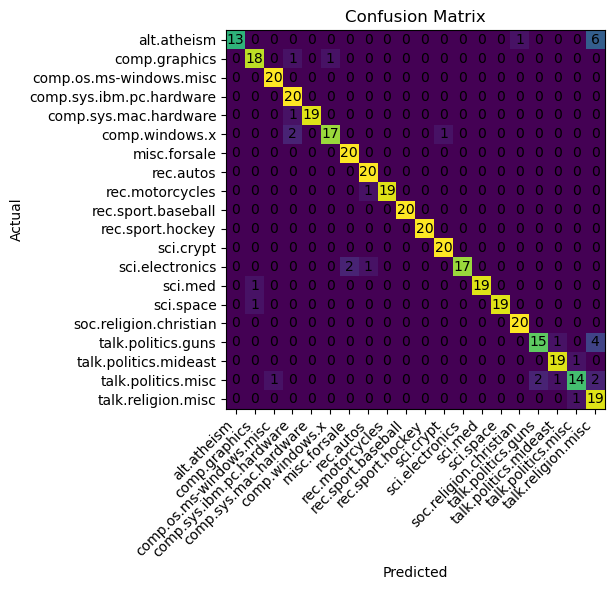

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print("Classification report:\n", classification_report(y_test, y_pred, zero_division=0))

labels_sorted = np.unique(y)
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)
print("Confusion matrix shape:", cm.shape)

fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(cm, interpolation='nearest')
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks(np.arange(len(labels_sorted)))
ax.set_yticks(np.arange(len(labels_sorted)))
ax.set_xticklabels(labels_sorted, rotation=45, ha="right")
ax.set_yticklabels(labels_sorted)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")
fig.tight_layout()
plt.show()


In [ ]:
import re

sentiment_method = None
try:
    from textblob import TextBlob
    sentiment_method = "textblob"
    def get_sentiment(text):
        p = TextBlob(text).sentiment.polarity
        if p > 0.1:
            return "positive"
        elif p < -0.1:
            return "negative"
        else:
            return "neutral"
    df['sentiment'] = df['Data'].fillna("").apply(get_sentiment)
except Exception:
    try:
        import nltk
        from nltk.sentiment import SentimentIntensityAnalyzer
        try:
            nltk.data.find('sentiment/vader_lexicon.zip')
        except Exception:
            nltk.download('vader_lexicon', quiet=True)
        sia = SentimentIntensityAnalyzer()
        sentiment_method = "vader"
        def get_sentiment(text):
            sc = sia.polarity_scores(text)['compound']
            if sc > 0.05:
                return "positive"
            elif sc < -0.05:
                return "negative"
            else:
                return "neutral"
        df['sentiment'] = df['Data'].fillna("").apply(get_sentiment)
    except Exception:
        sentiment_method = "lexicon_fallback"
        pos_words = {"good","great","excellent","happy","love","nice","fortunate","correct","super","awesome","best"}
        neg_words = {"bad","terrible","worst","sad","hate","awful","wrong","poor","problem","issue","angry"}
        def get_sentiment(text):
            words = re.findall(r'\w+', str(text).lower())
            if len(words) == 0:
                return "neutral"
            pos = sum(1 for w in words if w in pos_words)
            neg = sum(1 for w in words if w in neg_words)
            if pos - neg > 0:
                return "positive"
            elif neg - pos > 0:
                return "negative"
            else:
                return "neutral"
        df['sentiment'] = df['Data'].fillna("").apply(get_sentiment)

print("Sentiment method used:", sentiment_method)
print("Overall sentiment distribution:\n", df['sentiment'].value_counts())
display(df.groupby('Labels')['sentiment'].value_counts().unstack(fill_value=0).head(10))


Sentiment method used: vader
Overall sentiment distribution:
 sentiment
positive    1334
negative     631
neutral       35
Name: count, dtype: int64


sentiment,negative,neutral,positive
Labels,,,
alt.atheism,42,1,57
comp.graphics,13,4,83
comp.os.ms-windows.misc,24,2,74
comp.sys.ibm.pc.hardware,21,0,79
comp.sys.mac.hardware,24,3,73
comp.windows.x,20,2,78
misc.forsale,7,8,85
rec.autos,27,1,72
rec.motorcycles,30,2,68


In [10]:
import joblib
joblib.dump({'tfidf': tfidf, 'clf': clf}, 'D:\\DS Assignment\\nb_tfidf_model.joblib')
print("Saved model to D:\DS Assignment\\nb_tfidf_model.joblib")



Saved model to D:\DS Assignment\nb_tfidf_model.joblib
